# Graph Convolutional Network to Overcome Navigation Challenges

By: Apurvata Kumar

Updated: March 2026

In [663]:
# Import libraries
from numpy.random import geometric
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import torch.nn.functional as nf
import heapq

Change below file paths as needed.

In [664]:
# Import customized datasets
simple_file = '/content/custom_data_simple.csv'
# For both medium and complex datasets
complex_file = '/content/custom_data_complex.csv'

Using three types of datasets for three phases. I am commenting out the others when one dataset is in use.

Use country code/latitude/longitude keywords for the medium and complex dataset.

In [665]:
# Create dataset for "simple" phase
df = pd.read_csv(simple_file).iloc[2:53]

# Convert longitude and latitude to integer for simple phase
df['usa_state_longitude'] = df['usa_state_longitude'].fillna(0).astype(int)
df['usa_state_latitude'] = df['usa_state_latitude'].fillna(0).astype(int)

# Select 5 rows at random for 10 different sets (8 for training and 2 for testing)
df_simple1 = df.sample(n=5)
df_simple2 = df.sample(n=5)
df_simple3 = df.sample(n=5)
df_simple4 = df.sample(n=5)
df_simple5 = df.sample(n=5)
df_simple6 = df.sample(n=5)
df_simple7 = df.sample(n=5)
df_simple8 = df.sample(n=5)
# For testing
df_simple9 = df.sample(n=5)
df_simple10 = df.sample(n=5)

display(df_simple1)
display(df_simple2)

,usa_state_code,usa_state_latitude,usa_state_longitude
24,MO,37,-91
10,GA,32,-82
41,SC,33,-81
29,NE,41,-99
39,PR,18,-66


,usa_state_code,usa_state_latitude,usa_state_longitude
17,KY,37,-84
37,OR,43,-120
12,IA,41,-93
19,MA,42,-71
49,WI,43,-88


In [666]:
# Create dataset for "medium" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 10 rows at random for 10 different sets (8 for training and 2 for testing)
df_medium1 = df.sample(n=10)
df_medium2 = df.sample(n=10)
df_medium3 = df.sample(n=10)
df_medium4 = df.sample(n=10)
df_medium5 = df.sample(n=10)
df_medium6 = df.sample(n=10)
df_medium7 = df.sample(n=10)
df_medium8 = df.sample(n=10)
# For testing
df_medium9 = df.sample(n=10)
df_medium10 = df.sample(n=10)

display(df_medium1)
display(df_medium2)

,country_code,country_latitude,country_longitude
145,MP,17.330830,145.384690
238,WS,-13.759029,-172.104629
171,PF,-17.679742,-149.406843
152,MW,-13.254308,34.301525
128,LR,6.428055,-9.429499
161,NI,12.865416,-85.207229
185,RO,45.943161,24.966760
78,GH,7.946527,-1.023194
107,IT,41.871940,12.567380
26,BN,4.535277,114.727669


,country_code,country_latitude,country_longitude
13,AU,-25.274398,133.775136
169,PA,8.537981,-80.782127
202,SO,5.152149,46.199616
54,DJ,11.825138,42.590275
215,TL,-8.874217,125.727539
232,VE,6.423750,-66.589730
129,LS,-29.609988,28.233608
114,KH,12.565679,104.990963
111,JP,36.204824,138.252924
230,VA,41.902916,12.453389


In [667]:
# Create dataset for "complex" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 25 rows at random for 10 different sets (8 for training and 2 for testing)
df_complex1 = df.sample(n=25)
df_complex2 = df.sample(n=25)
df_complex3 = df.sample(n=25)
df_complex4 = df.sample(n=25)
df_complex5 = df.sample(n=25)
df_complex6 = df.sample(n=25)
df_complex7 = df.sample(n=25)
df_complex8 = df.sample(n=25)
# For testing
df_complex9 = df.sample(n=25)
df_complex10 = df.sample(n=25)

display(df_complex1)
display(df_complex2)

,country_code,country_latitude,country_longitude
193,SE,60.128161,18.643501
173,PH,12.879721,121.774017
124,LB,33.854721,35.862285
91,GZ,31.354676,34.308825
159,NF,-29.040835,167.954712
50,CX,-10.447525,105.690449
86,GS,-54.429579,-36.587909
181,PW,7.514980,134.582520
15,AZ,40.143105,47.576927
228,UY,-32.522779,-55.765835


,country_code,country_latitude,country_longitude
192,SD,12.862807,30.217636
122,KZ,48.019573,66.923684
51,CY,35.126413,33.429859
195,SH,-24.143474,-10.030696
227,US,37.090240,-95.712891
81,GM,13.443182,-15.310139
145,MP,17.330830,145.384690
124,LB,33.854721,35.862285
73,GB,55.378051,-3.435973
216,TM,38.969719,59.556278


If any of the data points are null, we can rerun the code to regenerate random values that are not null.

***For the below code, the dataset can be changed to other simple or complex sets created above.***

As an example, only one dataset is used for the program.

In [668]:
# Pick a dataset
data = df_simple9.copy()

In [669]:
# Normalize datasets between the range [0, 1] using MinMaxScalar
scaler = MinMaxScaler()

df_simple1_norm = data.copy()
columns = ['usa_state_latitude', 'usa_state_longitude']
df_simple1_norm[columns] = scaler.fit_transform(df_simple1_norm[columns])

display(df_simple1_norm)

,usa_state_code,usa_state_latitude,usa_state_longitude
42,SD,0.666667,0.428571
47,VT,1.000000,0.979592
37,OR,0.666667,0.000000
19,MA,0.333333,1.000000
38,PA,0.000000,0.877551


In [670]:
# Convert (longitude, latitude) to cartesian coordinates (x, y)
df_simple1_cart = df_simple1_norm.copy()
df_simple1_cart['x'] = df_simple1_norm['usa_state_longitude']
df_simple1_cart['y'] = df_simple1_norm['usa_state_latitude']

df_simple1_cart = df_simple1_cart[['usa_state_code', 'x', 'y']].copy()

display(df_simple1_cart)

,usa_state_code,x,y
42,SD,0.428571,0.666667
47,VT,0.979592,1.000000
37,OR,0.000000,0.666667
19,MA,1.000000,0.333333
38,PA,0.877551,0.000000


This step converts the imported dataset into a custom normalized version using cartesian coordinates with values between 0 and 1.

In [671]:
# Add random noise to reduce overfitting
noise_val = 0.0003

df_simple1_cart['x'] = df_simple1_cart['x'] + np.random.normal(0, noise_val, size=len(data))
df_simple1_cart['y'] = df_simple1_cart['y'] + np.random.normal(0, noise_val, size=len(data))

display(df_simple1_cart)

,usa_state_code,x,y
42,SD,0.428798,0.666494
47,VT,0.979441,1.000198
37,OR,0.000090,0.666605
19,MA,0.999586,0.333206
38,PA,0.877660,-0.000177


After dataset is customized, the nodes (state or country codes) can be represented as a graph with edges (distance between nodes).

In [672]:
# Set the customized/normalized dataset as the new data variable
data_custom = df_simple1_cart.copy()

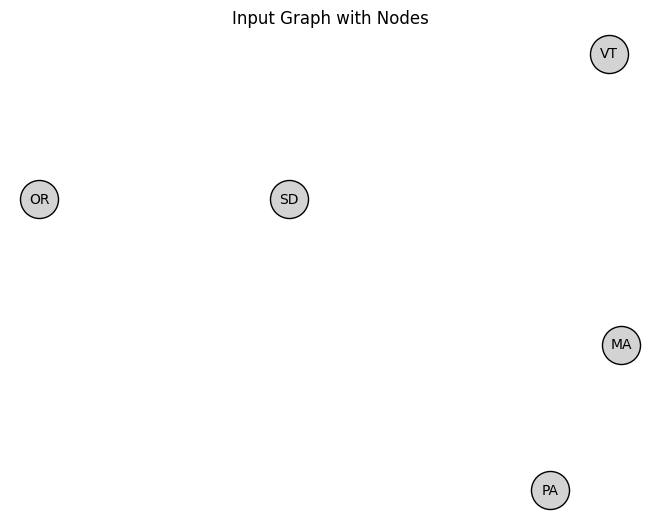

,usa_state_code,x,y
42,SD,0.428798,0.666494
47,VT,0.979441,1.000198
37,OR,0.000090,0.666605
19,MA,0.999586,0.333206
38,PA,0.877660,-0.000177


In [673]:
# Build a simple graph for the input
G = nx.Graph()

# Use state code as nodes
for id, row in data_custom.iterrows():
    G.add_node(row['usa_state_code'], pos=(row['x'], row['y']))

info = data_custom[['usa_state_code', 'x', 'y']]
pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes')
plt.show()

display(info)

Calculate the distance between nodes using the "Distance Formula":

***d = sqrt((x2 - x1)^2 + (y2 - y1)^2)***

Note: The distance is inversed because farther distance has lower weights on the edges.

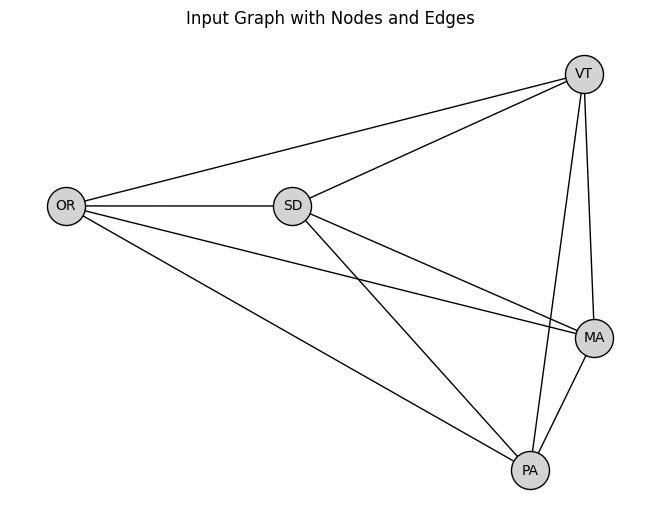

,usa_state_code,x,y
42,SD,0.428798,0.666494
47,VT,0.979441,1.000198
37,OR,0.000090,0.666605
19,MA,0.999586,0.333206
38,PA,0.877660,-0.000177


In [674]:
# Add edges based on the distance (inverse) between nodes
for i in range(len(info)):
  for j in range(i+1, len(info)):
    x1 = info.iloc[i]['x']
    x2 = info.iloc[j]['x']
    y1 = info.iloc[i]['y']
    y2 = info.iloc[j]['y']

    # Distance between nodes
    d = np.sqrt((x2-x1)**2 + (y2-y1)**2)

    # Weight of edges (inverse of distance = the farther the node, the lower the weight)
    w = 1/d if d>0 else 0

    G.add_edge(info.iloc[i]['usa_state_code'], info.iloc[j]['usa_state_code'], weight=w)

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes and Edges')
plt.show()

display(info)

Adding weights directly to the graph's edges. This is different than the weights/bias parameters in neural networks.

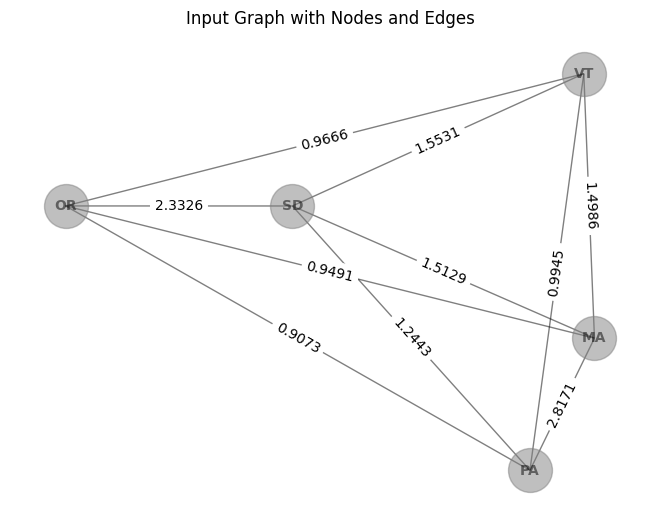

{('SD', 'VT'): np.float64(1.5531129435883886),
 ('SD', 'OR'): np.float64(2.3325922787436952),
 ('SD', 'MA'): np.float64(1.5129286908807242),
 ('SD', 'PA'): np.float64(1.244251067620136),
 ('VT', 'OR'): np.float64(0.9665502478680071),
 ('VT', 'MA'): np.float64(1.4985849407074838),
 ('VT', 'PA'): np.float64(0.9944913182979747),
 ('OR', 'MA'): np.float64(0.9490947608742848),
 ('OR', 'PA'): np.float64(0.9073203227789723),
 ('MA', 'PA'): np.float64(2.8170677356762206)}

In [675]:
from numpy.random.mtrand import f
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')

# Add weights with 4 decimal places (Gemini AI)
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}

# Draw edges
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)
plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))


Add random noise and remove 2-3 random edges to make it suitable for the input graph.

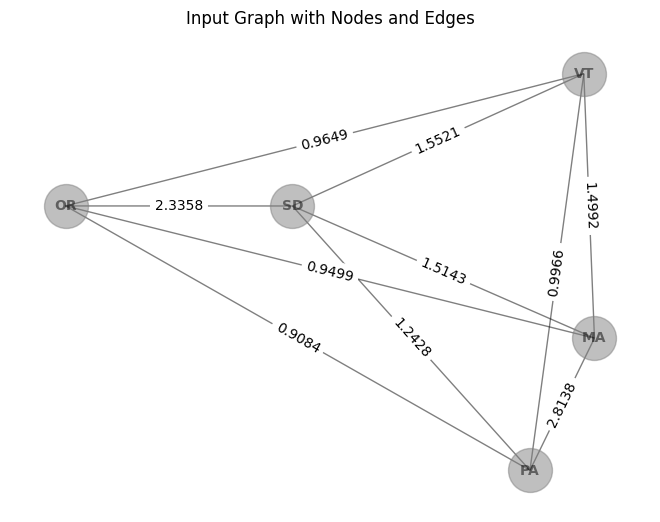

{('SD', 'VT'): np.float64(1.5521419582341236),
 ('SD', 'OR'): np.float64(2.335810849504399),
 ('SD', 'MA'): np.float64(1.5142894752987464),
 ('SD', 'PA'): np.float64(1.2427979631889317),
 ('VT', 'OR'): np.float64(0.9649285688002893),
 ('VT', 'MA'): np.float64(1.4992015530777276),
 ('VT', 'PA'): np.float64(0.9966217638806567),
 ('OR', 'MA'): np.float64(0.949856365645663),
 ('OR', 'PA'): np.float64(0.9083627254260377),
 ('MA', 'PA'): np.float64(2.8137639371727126)}

In [676]:
# Variables
random_noise = 0.003
edges_to_remove = 3
edge_threshold = 0.75
i = 0

# Remove "random_edges_to_remove" number of edges from the graph
while i < edges_to_remove:
  # Collect edges to remove
  collect_edges = []
  for u, v, data in G.edges(data=True):
    # Remove only edges that are less than "edge_threshold" because distance is too far
    if data['weight'] < edge_threshold:
      collect_edges.append((u, v))
    # If not removed, add random noise
    else:
      data['weight'] = data['weight'] + np.random.normal(0, random_noise)
    i+=1
  G.remove_edges_from(collect_edges)


# Draw graph again

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)

plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))



Find two random rows for source and destination for the input. If 0, retry the code until both are not null.

In [677]:
# Pick 2 random nodes

# Input Source
source = np.random.randint(0, len(data_custom))
# Input Destination
dest = np.random.randint(0, len(data_custom))

display(source, dest)

source_node = data_custom.iloc[source]
dest_node = data_custom.iloc[dest]

display(source_node, dest_node)

3

2

,19
usa_state_code,MA
x,0.999586
y,0.333206


,37
usa_state_code,OR
x,0.00009
y,0.666605


This data needs to be in tensor format in order to be used as data in the GNN/GCN model.

In [678]:
# Convert graph to tensor data
nodes = list(G.nodes)
edges = list(G.edges)

nodes_map = {node: i for i, node in enumerate(data_custom['usa_state_code'])}

tensor_map = []
for node in nodes:
  if node in nodes_map:
    node_tmp = nodes_map[node]
    tensor_map.append(data_custom.iloc[node_tmp][['x','y']].values)
  tensor_map.append([0.0, 0.0])

x = torch.tensor(tensor_map, dtype=torch.float)

source_tmp = [{name: i for i, name in enumerate(nodes)}[u] for u, v in edges]
dest_tmp = [{name: i for i, name in enumerate(nodes)}[v] for u, v in edges]

edge_index = torch.tensor([source_tmp, dest_tmp], dtype=torch.long)

# min, number of classification, size of layers, type)
y = torch.randint(0, 10, [2,4], dtype=torch.long)

# Create the data for the model
data = Data(x=x, edge_index=edge_index, y=y)

display(data)
display(data.num_nodes)
display(data.num_edges)

Data(x=[10, 2], edge_index=[2, 10], y=[2, 4])

10

10

In [679]:
# Parameters for Medium Phase
features = 2
input_size = 2
hidden_layer_size = 8
output_size = 2
num_hidden_layers = 3
learning_rate = 0.01
num_epochs = 100

# Parameters for Complex Phase
features = 2
input_size = 2
hidden_layer_size = 64
output_size = 2
num_hidden_layers = 5
learning_rate = 0.001
num_epochs = 100

# Parameters for Simple Phase
features = 2 # for x and y
input_size = 2
hidden_layer_size = 4
output_size = 2
num_hidden_layers = 2
learning_rate = 0.01
num_epochs = 100

In [680]:
# Create a GNN model for Simple Phase
class GNN(torch.nn.Module):
  def __init__(self, input_size, hidden_layer_size, output_size):
    super(GNN, self).__init__()
    self.conv1 = GCNConv(input_size, hidden_layer_size)
    self.conv2 = GCNConv(hidden_layer_size, output_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GNN(input_size, hidden_layer_size, output_size)

# Optimizer and Backpropagation
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
model.train()
output = model(data)
loss = nf.cross_entropy(output, data.x)
loss.backward()
optimizer.step()
print("This is the loss:")
display(loss.item())
print("")

# Display model
print("This is the model information:")
display(model)

This is the loss:


0.3931899964809418


This is the model information:


GNN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

In [681]:
# Create a GCN model for Simple Phase
class GCN(torch.nn.Module):
  def __init__(self, num_node_features, hidden_layer_size):
    super(GCN, self).__init__()
    self.conv1 = GCNConv(num_node_features, hidden_layer_size)
    self.conv2 = GCNConv(hidden_layer_size, output_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GCN(features, hidden_layer_size)

# Optimizer and Backpropagation
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
model.train()
output = model(data)
loss = nf.cross_entropy(output, data.x)
loss.backward()
optimizer.step()
print("This is the loss:")
display(loss.item())
print("")

# Display model
print("This is the model information:")
display(model)

This is the loss:


0.42801064252853394


This is the model information:


GCN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

Now that the model is defined, the A* method can be used in the output layer to find the optimized path from source_node to dest_node in the graph.

In this case, the edges are used to define the shortest path to keep the variables for the project simple.

In [682]:
# Create a distance function to reduce repetitive code
def distance(source, dest):
  # Source and Destination nodes
  x1 = nx.get_node_attributes(G, 'pos')[source][0]
  x2 = nx.get_node_attributes(G, 'pos')[dest][0]
  y1 = nx.get_node_attributes(G, 'pos')[source][1]
  y2 = nx.get_node_attributes(G, 'pos')[dest][1]

  # Distance between nodes
  return np.sqrt((x2-x1)**2 + (y2-y1)**2)

# Example distance calculation
display(float(distance(source_node['usa_state_code'], dest_node['usa_state_code'])))

1.0536355706766545

In [683]:
# A* algorithm for shortest path calculation
def a_star_search(G, source, dest):
  start = [(0, source, [source])]

  shortest_path = {node: float('inf') for node in G.nodes()}
  shortest_path[source] = 0

  optimal_path = {node: float('inf') for node in G.nodes()}
  optimal_path[source] = distance(source, dest)

  while start:
    # Build optimal path using node by node and path by path in a heap
    tmp_optimal_path, tmp_node, tmp_path = heapq.heappop(start)

    # If the current node is the destination node
    if tmp_node == dest:
      return tmp_path

    for neighbour in G.neighbors(tmp_node):
      x1 = nx.get_node_attributes(G, 'pos')[tmp_node][0]
      x2 = nx.get_node_attributes(G, 'pos')[neighbour][0]
      y1 = nx.get_node_attributes(G, 'pos')[tmp_node][1]
      y2 = nx.get_node_attributes(G, 'pos')[neighbour][1]

      # Distance between nodes
      d = distance(tmp_node, neighbour)

      # Calculate current shortest path and current optimal path
      if shortest_path[neighbour] > shortest_path[tmp_node] + d:
        # Current node and distance to neighbour
        shortest_path[neighbour] = shortest_path[tmp_node] + d
        # Neighbour and distance to destination
        optimal_path[neighbour] = shortest_path[neighbour] + distance(neighbour, dest)
        heapq.heappush(start, (optimal_path[neighbour], neighbour, tmp_path + [neighbour]))

  return "No Path Found."

In [684]:
# Find shortest path of the current graph
graph_shortest_path = a_star_search(G, source_node['usa_state_code'], dest_node['usa_state_code'])
display(graph_shortest_path)

['MA', 'OR']

In [685]:
# Find the total distance of this shortest path
if graph_shortest_path != 'No Path Found.':
  total_distance = 0
  for i in range(len(graph_shortest_path)-1):
    total_distance += distance(graph_shortest_path[i], graph_shortest_path[i+1])

  display(float(total_distance))

1.0536355706766545

The graph code above is used again to show the shortest path in different colours.

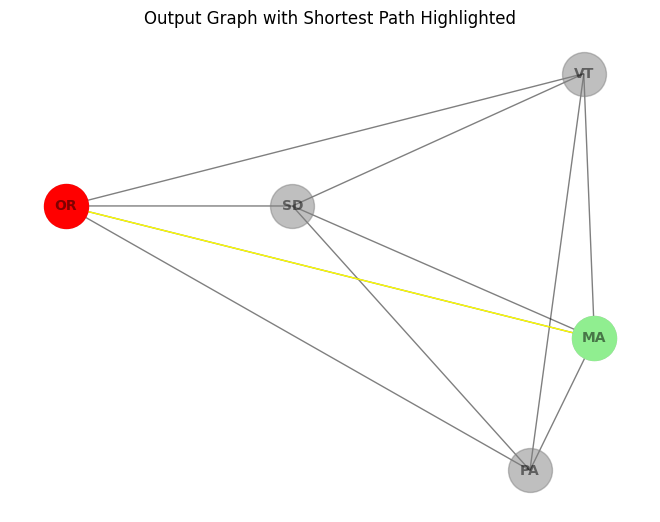

In [686]:
# Show the shortest path in the current graph
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_weight='bold', edge_color='black', alpha=0.5)

# Change colour of the shortest path
path_list = list(zip(graph_shortest_path, graph_shortest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_list, edge_color='yellow')

# Change colour of start node
nx.draw_networkx_nodes(G, pos, nodelist=[graph_shortest_path[0]], node_color='lightgreen', node_size=1000)

# Change colour of start node
nx.draw_networkx_nodes(G, pos, nodelist=[graph_shortest_path[1]], node_color='red', node_size=1000)

plt.title('Output Graph with Shortest Path Highlighted')
plt.show()

The pyTorch library provides the function to get probabilities as the output.

In [687]:
# Get output probabilities
model.eval()
with torch.no_grad():
  output = model(data)
  probabilities = torch.exp(output)

display(probabilities[source].numpy(), probabilities[dest].numpy())

array([0.6032606 , 0.39673945], dtype=float32)

array([0.5970535 , 0.40294644], dtype=float32)

In [688]:
# Training
losses = []
accuracies = []
for epoch in range(num_epochs):
  # Train the model
  model.train()
  # Clear gradients
  optimizer.zero_grad()
  # Adam optimizer
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  output = model(data)
  # Calculate loss
  loss = nf.cross_entropy(output, data.x)
  # Backpropagation
  loss.backward()
  # Updates model parameters
  optimizer.step()
  # Append to list of all losses for plotting
  losses.append(loss.item())
  # Print Epoch and Loss values
  print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Percent_Loss: {loss:.2%}')

  # Model Evaluation
  model.eval()
  with torch.no_grad():
    output = model(data)
    # Calculate probabilities or predicted values
    probabilities = torch.argmax(output, dim=1)
    # Calculate the correct or true values
    correct = torch.randint(0,2,(data.num_nodes,),dtype=torch.long)
    # Calculate the overall accuracy
    accuracy = (probabilities == correct).sum().item() / data.num_nodes
    # Append to list of all accuracies for plotting
    accuracies.append(accuracy)
    print(f'Accuracy: {accuracy:.4f}, Percent_Accuracy: {accuracy:.2%}')


Epoch: 00, Loss: 0.4261, Percent_Loss: 42.61%
Accuracy: 0.3000, Percent_Accuracy: 30.00%
Epoch: 01, Loss: 0.4244, Percent_Loss: 42.44%
Accuracy: 0.5000, Percent_Accuracy: 50.00%
Epoch: 02, Loss: 0.4231, Percent_Loss: 42.31%
Accuracy: 0.8000, Percent_Accuracy: 80.00%
Epoch: 03, Loss: 0.4220, Percent_Loss: 42.20%
Accuracy: 0.7000, Percent_Accuracy: 70.00%
Epoch: 04, Loss: 0.4209, Percent_Loss: 42.09%
Accuracy: 0.4000, Percent_Accuracy: 40.00%
Epoch: 05, Loss: 0.4200, Percent_Loss: 42.00%
Accuracy: 0.4000, Percent_Accuracy: 40.00%
Epoch: 06, Loss: 0.4190, Percent_Loss: 41.90%
Accuracy: 0.5000, Percent_Accuracy: 50.00%
Epoch: 07, Loss: 0.4181, Percent_Loss: 41.81%
Accuracy: 0.6000, Percent_Accuracy: 60.00%
Epoch: 08, Loss: 0.4172, Percent_Loss: 41.72%
Accuracy: 0.5000, Percent_Accuracy: 50.00%
Epoch: 09, Loss: 0.4165, Percent_Loss: 41.65%
Accuracy: 0.2000, Percent_Accuracy: 20.00%
Epoch: 10, Loss: 0.4157, Percent_Loss: 41.57%
Accuracy: 0.4000, Percent_Accuracy: 40.00%
Epoch: 11, Loss: 0.41

In [689]:
# Testing
model.eval()
output = model(data)
probabilities = torch.argmax(output, dim=1)
correct = torch.randint(0,2,(data.num_nodes,),dtype=torch.long)
accuracy = (probabilities == correct).sum().item() / data.num_nodes
print(f'Accuracy: {accuracy:.4f}, Percent_Accuracy: {accuracy:.2%}')

display(probabilities[source].numpy(), probabilities[dest].numpy())

Accuracy: 0.8000, Percent_Accuracy: 80.00%


array(1)

array(1)

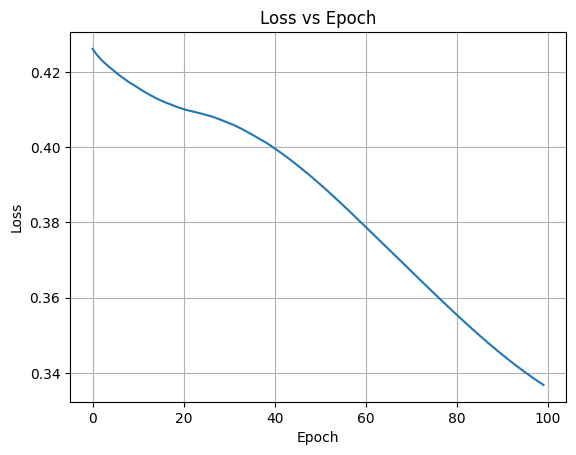

In [690]:
# Plot Loss vs Epochs
plt.plot(range(num_epochs), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.grid(True)
plt.show()

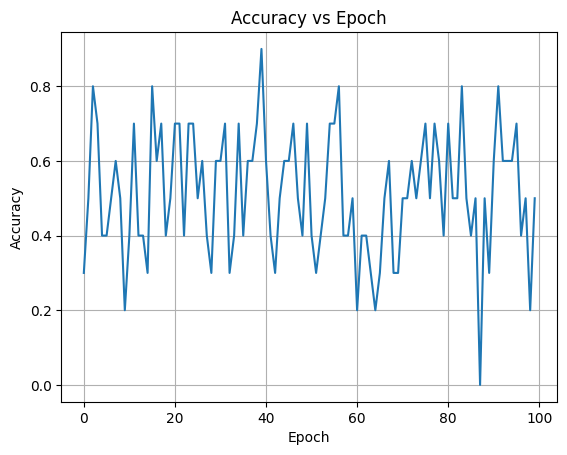

In [691]:
# Plot Loss vs Accuracy
plt.plot(range(num_epochs), accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.grid(True)
plt.show()

Additional Parameters for Experiments:

In [692]:
# Parameters for Medium Phase
features = 2
input_size = 2
hidden_layer_size = 8
output_size = 2
num_hidden_layers = 3
learning_rate = 0.01

# Parameters for Complex Phase
features = 2
input_size = 2
hidden_layer_size = 64
output_size = 2
num_hidden_layers = 5
learning_rate = 0.001